In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

np.random.seed(42)

warnings.filterwarnings("ignore")

%matplotlib inline

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 1) 数据：线性ARMA + 非线性外生驱动
def generate_synthetic_series(n=900):
    t = np.arange(n)
    # 外生特征（具有明显非线性与交互可能）
    x1 = np.sin(2*np.pi*t/50) + 0.3*np.sin(2*np.pi*t/5) + 0.1*np.random.randn(n)     # 强烈周期+噪声
    x2 = np.cos(2*np.pi*t/90) + 0.5*(t/n) + 0.15*np.random.randn(n)                  # 慢周期+轻趋势
    x3 = np.random.randn(n)                                                          # 噪声型特征
    x4 = (np.sin(2*np.pi*t/20) > 0).astype(float)                                    # 二值波动
    # X = np.column_stack([x1, x2, x3, x4])

    # 线性ARMA(2,1)生成过程
    e = 0.6*np.random.randn(n)  # 创噪
    y_lin = np.zeros(n)
    for i in range(2, n):
        y_lin[i] = 0.6*y_lin[i-1] - 0.3*y_lin[i-2] + e[i] + 0.4*e[i-1] + 0.01*t[i]  # 轻微线性趋势

    # 非线性外生驱动（用一些非线性组合）
    g = (1.5*np.sin(2*np.pi*t/30)*(x1>0).astype(float) +
         0.8*(x2**2) -
         1.2*np.maximum(x3 - 0.5, 0) +
         0.5*x4*np.sin(2*np.pi*t/10) +
         0.3*(x1*x2))

    y = y_lin + g + 0.35*np.random.randn(n)  # 加总并加噪

    df = pd.DataFrame({
        'y': y,
        'x1': x1, 'x2': x2, 'x3': x3, 'x4': x4
    })
    return df

df = generate_synthetic_series(n=900)
df

,y,x1,x2,x3,x4
0,-1.063153,0.049671,1.055301,1.901191,0.0
1,1.171427,0.396824,0.939119,-0.060661,1.0
2,4.231690,0.489794,0.995691,-0.708407,1.0
3,4.597157,0.344092,1.171582,-1.513714,1.0
4,3.722271,0.173021,0.992149,-1.803140,1.0
...,...,...,...,...,...
895,14.377413,-0.522914,1.324119,1.431367,0.0
896,13.527801,-0.213149,1.411181,1.081767,0.0
897,14.807760,-0.177118,1.357077,-1.312219,0.0
898,14.462625,-0.304375,1.650558,0.622070,0.0


In [3]:
# 2) 切分训练与测试
train_ratio = 0.8
n = len(df)
split_idx = int(n * train_ratio)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

y_train = train_df['y'].values
y_test  = test_df['y'].values

# 3) 仅对 y 使用 ARIMA 拟合线性部分
#    这里为了简化，使用 ARMA(2,1) 即 d=0；在真实任务中可使用自动定阶或检验。
arima_order = (2, 0, 1)
arima_model = ARIMA(y_train, order=arima_order)
arima_fit   = arima_model.fit()

# In-sample 线性预测（训练期）
yhat_arima_train = arima_fit.predict(start=0, end=len(y_train)-1)

# Out-of-sample 线性预测（测试期）
yhat_arima_test = arima_fit.forecast(steps=len(y_test))

# 残差（训练期）
resid_train = y_train - yhat_arima_train

# 4) 构造随机森林的训练特征：
#    使用外生变量 + ARIMA预测值（作为上下文）+ 残差滞后
def make_rf_train_matrix(train_df, yhat_arima_train, resid_train, lag=2):
    X_cols = ['x1', 'x2', 'x3', 'x4']
    X_base = train_df[X_cols].values

    # 构造滞后残差
    resid_lags = []
    for L in range(1, lag+1):
        lag_arr = np.concatenate([np.full(L, np.nan), resid_train[:-L]])
        resid_lags.append(lag_arr)
    resid_lags = np.column_stack(resid_lags)

    # 合并：外生、ARIMA预测、残差滞后
    X_rf = np.column_stack([X_base, yhat_arima_train, resid_lags])

    # 目标：当前残差
    y_rf = resid_train.copy()

    # 去掉因滞后产生的 NaN
    valid_idx = ~np.any(np.isnan(resid_lags), axis=1)
    X_rf = X_rf[valid_idx]
    y_rf = y_rf[valid_idx]
    return X_rf, y_rf, valid_idx

X_rf_train, y_rf_train, valid_idx_train = make_rf_train_matrix(train_df, yhat_arima_train, resid_train, lag=2)

feature_names = ['x1','x2','x3','x4','arima_pred','resid_lag1','resid_lag2']

In [4]:
# 5) 训练随机森林（使用标准化+RF的Pipeline）
rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])
rf.fit(X_rf_train, y_rf_train)

# 6) 训练期的混合预测
#    RF 对齐后的训练期预测（注意索引对齐）
rf_pred_train = rf.predict(X_rf_train)
# 将预测贴回到对应时间索引：valid_idx_train为True的部分有RF预测
y_hybrid_train = yhat_arima_train.copy()
y_hybrid_train[valid_idx_train] += rf_pred_train

# 7) 测试期的混合预测（递归式生成残差滞后）
def hybrid_forecast_test(test_df, yhat_arima_test, last_resid_hist, rf, lag=2):
    # last_resid_hist: 来自训练期最后的若干真实残差（作为初始滞后）
    # 递归预测测试期残差，避免数据泄漏
    X_cols = ['x1','x2','x3','x4']
    X_base = test_df[X_cols].values
    T = len(test_df)
    rf_resid_pred = np.zeros(T)

    # 维护一个队列存放最近滞后残差（先用训练期真实残差初始化）
    resid_queue = list(last_resid_hist[-lag:])  # ensure length == lag

    for t in range(T):
        # 构造当前特征：外生、ARIMA预测、滞后残差
        cur_features = np.array(list(X_base[t]) + [yhat_arima_test[t]] + resid_queue)
        cur_features = cur_features.reshape(1, -1)
        cur_resid_pred = rf.predict(cur_features)[0]
        rf_resid_pred[t] = cur_resid_pred

        # 更新队列：插入最新预测残差，弹出最老
        resid_queue = [cur_resid_pred] + resid_queue[:lag-1]

    y_hybrid_test = yhat_arima_test + rf_resid_pred
    return y_hybrid_test, rf_resid_pred

# 用训练期最后的真实残差作为测试期递归的初值
last_resid_hist = resid_train[-5:]  # 保留多个，函数里只用到lag个
y_hybrid_test, rf_resid_pred_test = hybrid_forecast_test(test_df, yhat_arima_test, last_resid_hist, rf, lag=2)

In [5]:
# 8) 评估指标
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return rmse, mae, mape

rmse_arima_test, mae_arima_test, mape_arima_test   = metrics(y_test, yhat_arima_test)
rmse_hybrid_test, mae_hybrid_test, mape_hybrid_test = metrics(y_test, y_hybrid_test)

print("ARIMA 测试期: RMSE=%.3f, MAE=%.3f, MAPE=%.2f%%" % (rmse_arima_test, mae_arima_test, mape_arima_test))
print("Hybrid 测试期: RMSE=%.3f, MAE=%.3f, MAPE=%.2f%%" % (rmse_hybrid_test, mae_hybrid_test, mape_hybrid_test))


ARIMA 测试期: RMSE=2.525, MAE=2.127, MAPE=16.87%
Hybrid 测试期: RMSE=2.356, MAE=1.993, MAPE=15.78%


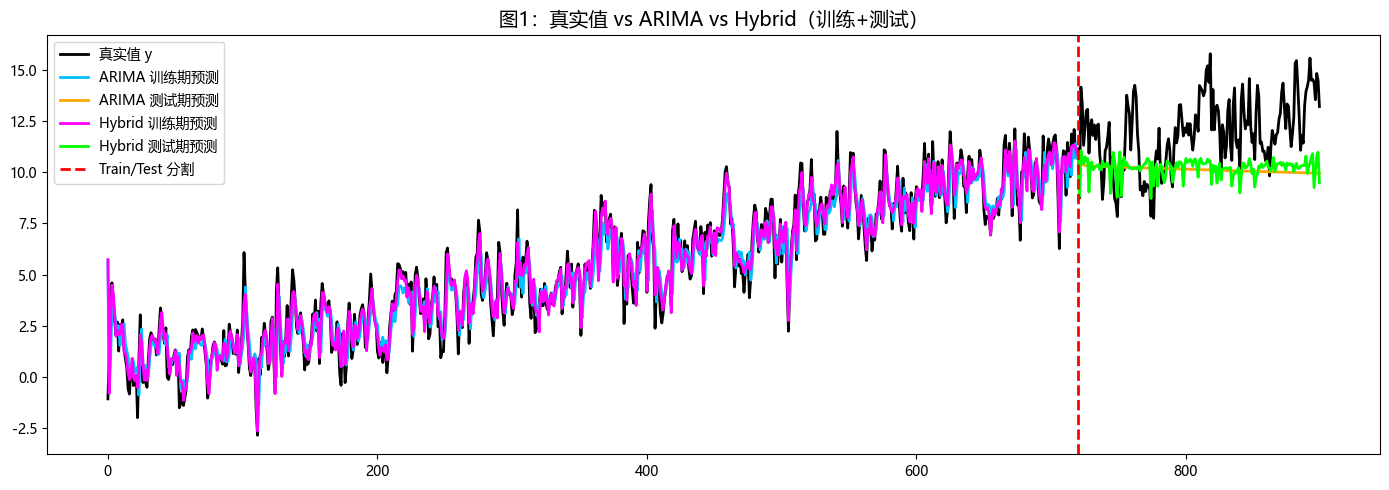

In [6]:
# 9) 可视化分析

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['y'].values, color='black', lw=2, label='真实值 y')
plt.plot(train_df.index, yhat_arima_train, color='deepskyblue', lw=2, label='ARIMA 训练期预测')
plt.plot(test_df.index, yhat_arima_test, color='orange', lw=2, label='ARIMA 测试期预测')
plt.plot(train_df.index, y_hybrid_train, color='magenta', lw=2, label='Hybrid 训练期预测')
plt.plot(test_df.index, y_hybrid_test, color='lime', lw=2, label='Hybrid 测试期预测')
plt.axvline(x=split_idx, color='red', lw=2, linestyle='--', label='Train/Test 分割')
plt.title('图1：真实值 vs ARIMA vs Hybrid（训练+测试）', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

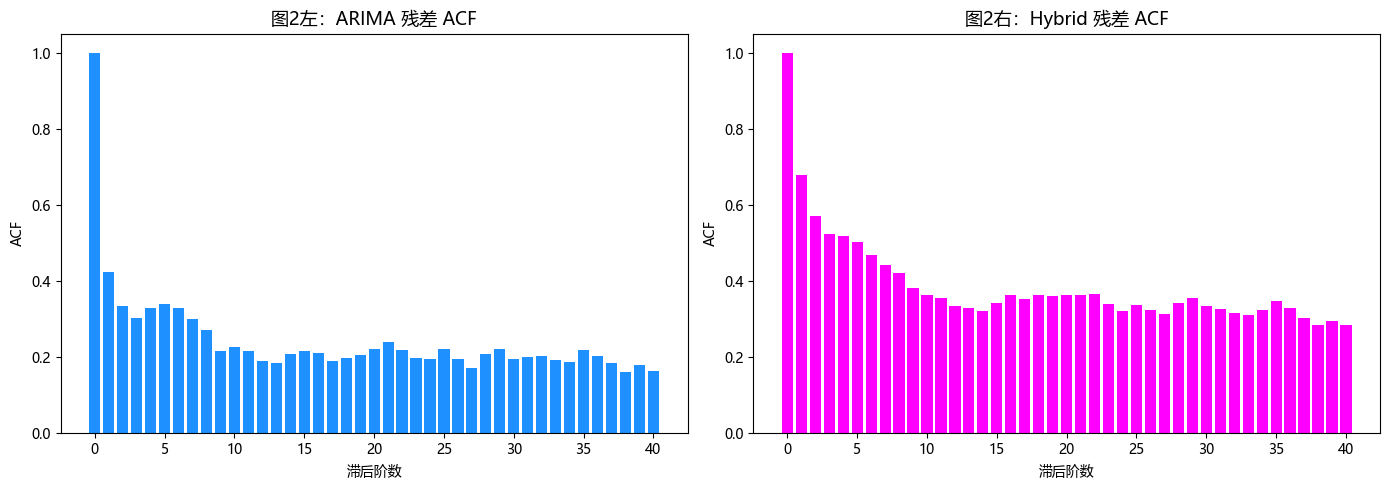

In [7]:
# 图2：残差自相关函数（ACF）对比：ARIMA残差 vs Hybrid残差（全期）
resid_arima_full = np.concatenate([resid_train, y_test - yhat_arima_test])
resid_hybrid_full = df['y'].values.copy()
resid_hybrid_full[:len(y_hybrid_train)] -= y_hybrid_train
resid_hybrid_full[len(y_hybrid_train):] -= y_hybrid_test

lags = 40
acf_arima = acf(resid_arima_full, nlags=lags, fft=True)
acf_hybrid = acf(resid_hybrid_full, nlags=lags, fft=True)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.bar(range(lags+1), acf_arima, color='dodgerblue')
plt.title('图2左：ARIMA 残差 ACF', fontsize=13)
plt.xlabel('滞后阶数')
plt.ylabel('ACF')

plt.subplot(1,2,2)
plt.bar(range(lags+1), acf_hybrid, color='fuchsia')
plt.title('图2右：Hybrid 残差 ACF', fontsize=13)
plt.xlabel('滞后阶数')
plt.ylabel('ACF')

plt.tight_layout()
plt.show()

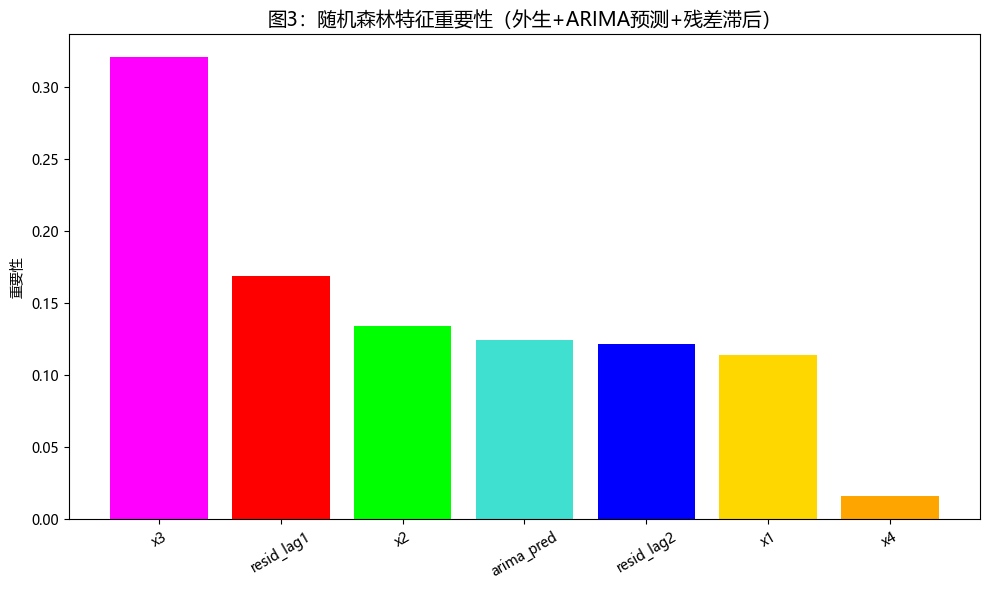

In [8]:
# 图3：随机森林特征重要性
rf_model = rf.named_steps['rf']
importances = rf_model.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
colors = ['gold','lime','magenta','orange','turquoise','red','blue']
plt.bar(np.array(feature_names)[order], importances[order], color=np.array(colors)[order])
plt.title('图3：随机森林特征重要性（外生+ARIMA预测+残差滞后）', fontsize=14)
plt.ylabel('重要性')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

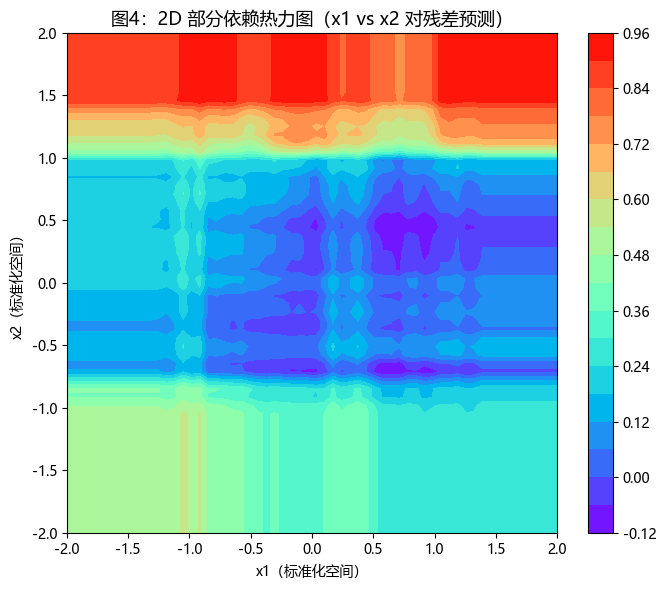

In [9]:
# 图4：2D 部分依赖（x1, x2 对残差预测的影响热力图）
def partial_dependence_2d(rf_pipeline, feature_idx_1, feature_idx_2, base_vector, grid1, grid2):
    # base_vector 的长度应与训练特征一致，代表其他特征的固定值
    Z = np.zeros((len(grid1), len(grid2)))
    for i, v1 in enumerate(grid1):
        for j, v2 in enumerate(grid2):
            vec = base_vector.copy()
            vec[feature_idx_1] = v1
            vec[feature_idx_2] = v2
            Z[i, j] = rf_pipeline.predict(vec.reshape(1, -1))[0]
    return Z

# 构造 base_vector：用训练期中位数或0填充
X_base_train_median = np.median(X_rf_train, axis=0)  # 对齐到RF训练特征空间
# x1,x2 分别是特征索引 0,1；其余保持为训练期中位数。
grid1 = np.linspace(-2, 2, 60)
grid2 = np.linspace(-2, 2, 60)
Z = partial_dependence_2d(rf, 0, 1, X_base_train_median, grid1, grid2)

plt.figure(figsize=(7,6))
cp = plt.contourf(grid1, grid2, Z.T, levels=20, cmap='rainbow')
plt.colorbar(cp)
plt.title('图4：2D 部分依赖热力图（x1 vs x2 对残差预测）', fontsize=13)
plt.xlabel('x1（标准化空间）')
plt.ylabel('x2（标准化空间）')
plt.tight_layout()
plt.show()

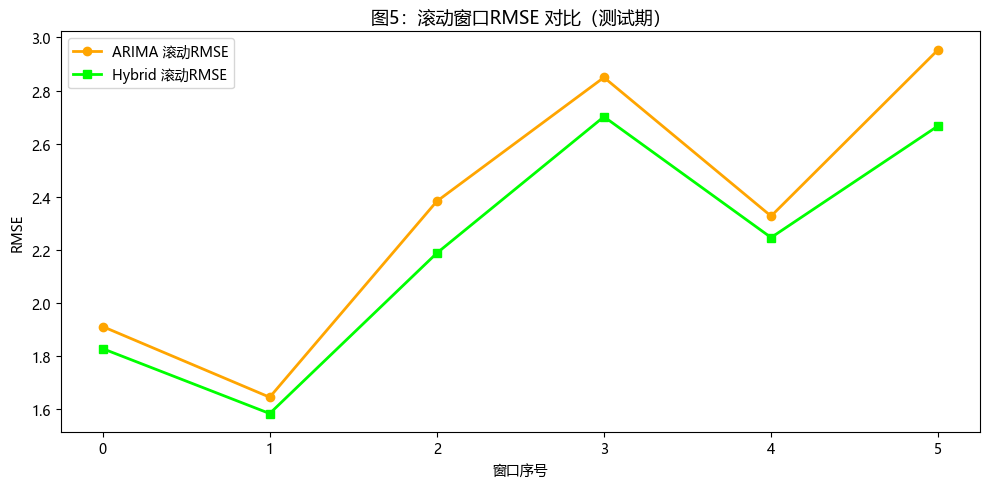

—— 测试期整体对比 ——
ARIMA:  RMSE=2.525, MAE=2.127, MAPE=16.87%
Hybrid: RMSE=2.356, MAE=1.993, MAPE=15.78%
Hybrid 相对 RMSE 改善: 6.70%


In [10]:
# 图5：滚动窗口RMSE 对比（ARIMA vs Hybrid）
window = 50
errors_arima = []
errors_hybrid = []
idxs = np.arange(len(y_test))
for start in range(0, len(y_test)-window+1, window//2):
    end = start + window
    rmse_a = np.sqrt(mean_squared_error(y_test[start:end], yhat_arima_test[start:end]))
    rmse_h = np.sqrt(mean_squared_error(y_test[start:end], y_hybrid_test[start:end]))
    errors_arima.append(rmse_a)
    errors_hybrid.append(rmse_h)

plt.figure(figsize=(10,5))
plt.plot(np.arange(len(errors_arima)), errors_arima, color='orange', lw=2, marker='o', label='ARIMA 滚动RMSE')
plt.plot(np.arange(len(errors_hybrid)), errors_hybrid, color='lime', lw=2, marker='s', label='Hybrid 滚动RMSE')
plt.title('图5：滚动窗口RMSE 对比（测试期）', fontsize=13)
plt.xlabel('窗口序号')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

# 额外打印对比说明
print("—— 测试期整体对比 ——")
print("ARIMA:  RMSE=%.3f, MAE=%.3f, MAPE=%.2f%%" % (rmse_arima_test, mae_arima_test, mape_arima_test))
print("Hybrid: RMSE=%.3f, MAE=%.3f, MAPE=%.2f%%" % (rmse_hybrid_test, mae_hybrid_test, mape_hybrid_test))
improve = (rmse_arima_test - rmse_hybrid_test)/rmse_arima_test*100
print("Hybrid 相对 RMSE 改善: %.2f%%" % improve)